# Analisis Sentimen Ulasan Film Menggunakan Metode Naïve Bayes

Nama : Queenly Vania Metanoia Napitupulu
NIM : A11.2024.15903
Kelas :A11.64405

Mata Kuliah : Machine Learning

# 1. Import Library


In [106]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import joblib

import nltk

from nltk.tokenize import ToktokTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# 2. Download NLTK Resources

In [107]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# 3. Load Dataset

In [108]:
df = pd.read_csv("/content/IMDB Dataset.csv")

# 4. Preprocessing

## 4.1 Lowercase

In [109]:
df["review"] = df["review"].str.lower()

df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


## 4.2 Hapus Tag HTML

In [110]:
def remove_html(text):
    return re.sub(r"<.*?>", "", text)

df["review"] = df["review"].apply(remove_html)

df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


## 4.3 Hapus URL

In [111]:
def remove_url(text):
    return re.sub(r"http\S+|www\S+", "", text)

df["review"] = df["review"].apply(remove_url)

df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


## 4.4 Hapus Tanda Baca

In [112]:
def remove_punctuation(text):
    return text.translate(str.maketrans("", "", string.punctuation))

df["review"] = df["review"].apply(remove_punctuation)

df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


## 4.5 Hapus Angka

In [113]:
def remove_numbers(text):
    return re.sub(r"\d+", "", text)

df["review"] = df["review"].apply(remove_numbers)

df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


## 4.6 Hapus Spasi Berlebih

In [114]:
def remove_spaces(text):
    return re.sub(r"\s+", " ", text).strip()

df["review"] = df["review"].apply(remove_spaces)

df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


## 4.7 Tokenization

In [115]:
tokenizer = ToktokTokenizer()

df["tokens"] = df["review"].apply(tokenizer.tokenize)

df[["review", "tokens"]].head()

,review,tokens
0,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione..."
1,a wonderful little production the filming tech...,"[a, wonderful, little, production, the, filmin..."
2,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,..."
3,basically theres a family where a little boy j...,"[basically, theres, a, family, where, a, littl..."
4,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon..."


## 4.8 Stopword Removal

In [116]:
stop_words = set(stopwords.words("english"))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df["tokens"] = df["tokens"].apply(remove_stopwords)

## 4.9 Lemmatization

In [117]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df["tokens"] = df["tokens"].apply(lemmatize_tokens)

## 4.10 Gabung Token

In [118]:
df["clean_review"] = df["tokens"].apply(lambda x: " ".join(x))

df[["clean_review"]].head()

,clean_review
0,one reviewer mentioned watching oz episode you...
1,wonderful little production filming technique ...
2,thought wonderful way spend time hot summer we...
3,basically there family little boy jake think t...
4,petter matteis love time money visually stunni...


# 5. TF-IDF Vectorization


In [119]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_review"])

y = df["sentiment"]

print(X.shape)

(50000, 5000)


#6. # Train-Test Split

In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Training :", X_train.shape)
print("Data Testing  :", X_test.shape)

Data Training : (40000, 5000)
Data Testing  : (10000, 5000)


# 7. Model 1 - Multinomial Naïve Bayes

## 7.1 Training Model Naïve Bayes

In [121]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

MultinomialNB()

## 7.2 Prediksi

In [122]:
y_pred_nb = nb_model.predict(X_test)

## 7.3 Accuracy

In [123]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print(f"Accuracy Naïve Bayes : {accuracy_nb:.4f}")

Accuracy Naïve Bayes : 0.8523


## 7.4 Classification Report

In [124]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

    negative       0.86      0.85      0.85      5000
    positive       0.85      0.86      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



## 7.5 Confussion Matrix

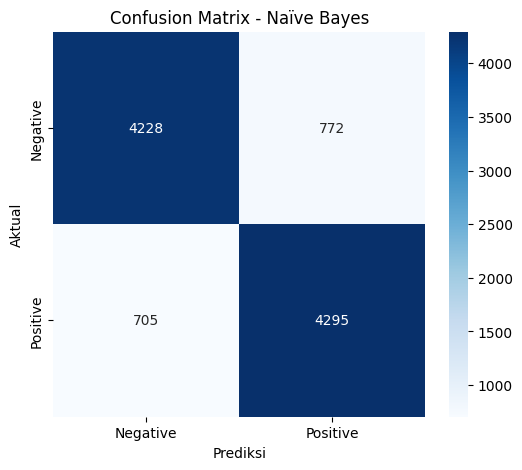

In [125]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative","Positive"],
    yticklabels=["Negative","Positive"]
)

plt.title("Confusion Matrix - Naïve Bayes")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.show()

# 8. Model 2 - Logistic Regression

## 8.1 Training Logistic Regression

In [126]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## 8.2 Prediksi Logistic Regression

In [127]:
y_pred_lr = lr_model.predict(X_test)

## 8.3 Accuracy

In [128]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print(f"Accuracy Logistic Regression : {accuracy_lr:.4f}")

Accuracy Logistic Regression : 0.8857


## 8.4 Classification Report

In [129]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

    negative       0.90      0.87      0.88      5000
    positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



## 8.5 Confussion Matrix

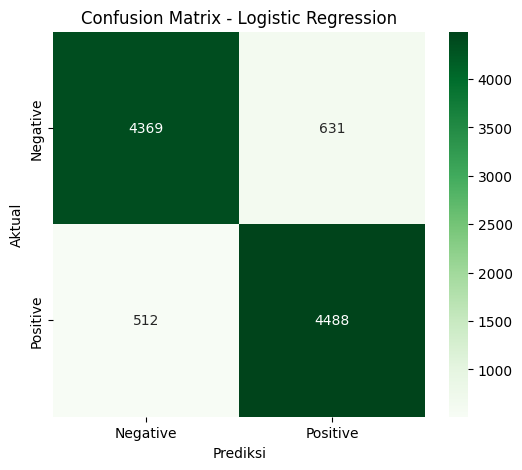

In [130]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Negative","Positive"],
    yticklabels=["Negative","Positive"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.show()

# 9. Hyperparameter Tuning

## 9.1 GridSearchCV

In [131]:
param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10]}, scoring='accuracy')

## 9.2 Best Parameter

In [132]:
print("Best Parameter :")

print(grid.best_params_)

Best Parameter :
{'C': 1}


## 9.3 Best Score

In [133]:
print("Best CV Accuracy :")

print(grid.best_score_)

Best CV Accuracy :
0.8821749999999999


## 9.4 Model Terbaik

In [134]:
best_model = grid.best_estimator_

## 9.5 Prediksi Model Terbaik

In [135]:
y_pred_best = best_model.predict(X_test)

## 9.6 Accuracy Model Terbaik

In [136]:
accuracy_best = accuracy_score(
    y_test,
    y_pred_best
)

print(f"Accuracy Best Model : {accuracy_best:.4f}")

Accuracy Best Model : 0.8857


# 10. ROC Curve

# 10.1 ROC Curve Naive Bayes

In [137]:
y_prob_nb = nb_model.predict_proba(X_test)[:,1]

fpr_nb, tpr_nb, _ = roc_curve(
    y_test.map({"negative":0,"positive":1}),
    y_prob_nb
)

auc_nb = roc_auc_score(
    y_test.map({"negative":0,"positive":1}),
    y_prob_nb
)

## 10.2 ROC Curve Logistic Regression

In [138]:
y_prob_lr = best_model.predict_proba(X_test)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(
    y_test.map({"negative":0,"positive":1}),
    y_prob_lr
)

auc_lr = roc_auc_score(
    y_test.map({"negative":0,"positive":1}),
    y_prob_lr
)

## 10.3 Visualisasi ROC Curve

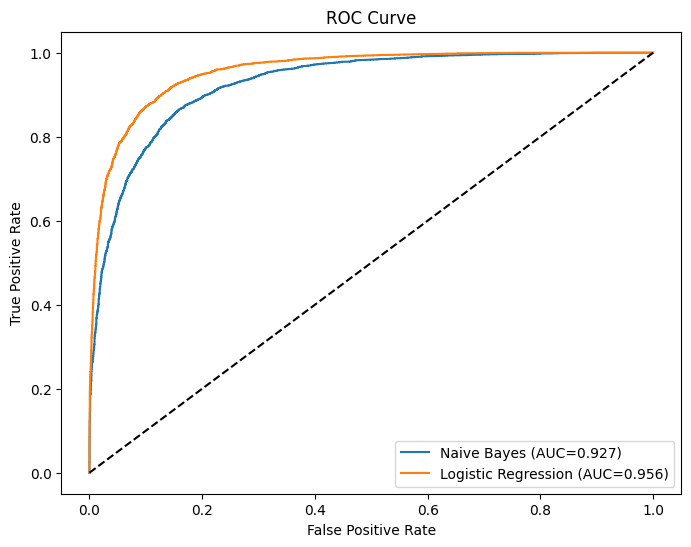

In [139]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr_nb,
    tpr_nb,
    label=f"Naive Bayes (AUC={auc_nb:.3f})"
)

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC={auc_lr:.3f})"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# 11. Perbandingan Model

## 11.1 Tabel Perbandingan

In [140]:
comparison = pd.DataFrame({

    "Model":[
        "Naive Bayes",
        "Logistic Regression"
    ],

    "Accuracy":[
        accuracy_nb,
        accuracy_best
    ],

    "ROC-AUC":[
        auc_nb,
        auc_lr
    ]

})

comparison

,Model,Accuracy,ROC-AUC
0,Naive Bayes,0.8523,0.926854
1,Logistic Regression,0.8857,0.956252


## 11.2 Visualisasi Perbandingan

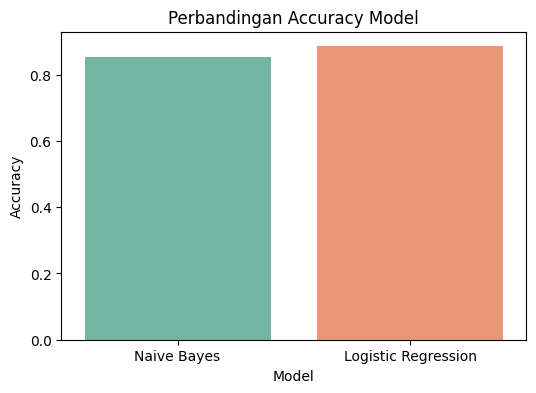

In [141]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="Set2",
    legend=False
)

plt.title("Perbandingan Accuracy Model")

plt.show()

# 12. Pengujian Data Baru

## 12.1 Fungsi Preprocessing

In [142]:
tokenizer = ToktokTokenizer()
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Remove HTML
    text = re.sub(r"<.*?>", "", text)

    # Remove URL
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove Punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove Numbers
    text = re.sub(r"\d+", "", text)

    # Remove Extra Spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization
    tokens = tokenizer.tokenize(text)

    # Stopword Removal
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

## 12.2 Pengujian Data Baru

In [143]:
review_baru = [
    "WOW I LOVE THIS MOVIE"
]

review_clean = [preprocess_text(text) for text in review_baru]

review_vector = vectorizer.transform(review_clean)

prediction = best_model.predict(review_vector)

probability = best_model.predict_proba(review_vector)

print("Review :", review_baru[0])
print("Hasil Prediksi :", prediction[0])
print("Confidence :", probability.max())

Review : WOW I LOVE THIS MOVIE
Hasil Prediksi : positive
Confidence : 0.7096644400577197


# 13. Simpan Model

In [144]:
joblib.dump(best_model, "best_model.pkl")

joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

# 14. Uji File yang Disimpan

In [145]:
loaded_model = joblib.load("best_model.pkl")

loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

review = ["This movie is amazing"]

review_clean = [preprocess_text(text) for text in review]

vector = loaded_vectorizer.transform(review_clean)

hasil = loaded_model.predict(vector)

print(hasil)

['positive']


# Kesimpulan

Berdasarkan hasil evaluasi yang dilakukan terhadap dua algoritma klasifikasi, yaitu Multinomial Naïve Bayes dan Logistic Regression, model terbaik dipilih berdasarkan nilai Accuracy dan ROC-AUC tertinggi.

Model terbaik kemudian disimpan menggunakan Joblib agar dapat digunakan kembali pada aplikasi Streamlit tanpa perlu melakukan proses pelatihan ulang.